# StyleSense: Fashion Forward Forecasting
## Predicting Customer Product Recommendations

**Course:** Data Science Pipeline Project  
**Dataset:** Women's Clothing E-Commerce Reviews  

---

### Project Overview

StyleSense, a fast-growing online women's clothing retailer, has accumulated a large backlog of product reviews where customers have left valuable text feedback but have not explicitly indicated whether they recommend the product.

This notebook builds a **supervised machine learning pipeline** to predict the `Recommended IND` target (1 = recommends, 0 = does not recommend) using:

- **Text data** — review title and body (TF-IDF with NLP preprocessing)
- **Numerical data** — customer age, positive feedback count
- **Categorical data** — division name, department name, class name

The pipeline handles all preprocessing, feature engineering, model training, hyperparameter tuning, and evaluation in a single end-to-end structure — ready for both training and inference.

---

### Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Load & Inspect Data](#2-load--inspect-data)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Train / Test Split](#5-train--test-split)
6. [Pipeline Construction](#6-pipeline-construction)
7. [Initial Training & Evaluation](#7-initial-training--evaluation)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)
9. [Final Evaluation](#9-final-evaluation)


---
## 1. Setup & Imports

In [1]:
import sys
!{sys.executable} -m pip install textblob joblib matplotlib seaborn scikit-learn nltk pandas numpy -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [27]:
# ── Standard library ──────────────────────────────────────────
import re
import warnings
warnings.filterwarnings("ignore")

# ── Data manipulation ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# ── NLP ────────────────────────────────────────────────────────
import nltk
import nltk
nltk.download("stopwords",                      quiet=True)
nltk.download("punkt",                          quiet=True)
nltk.download("punkt_tab",                      quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
from textblob import TextBlob

# ── Serialisation ──────────────────────────────────────────────
import joblib

# ── Scikit-learn: preprocessing ────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# ── Scikit-learn: model & pipeline ─────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Scikit-learn: evaluation & tuning ──────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

# ── Reproducibility ────────────────────────────────────────────
RANDOM_STATE = 42
LABEL_MAP    = {1: "Recommended", 0: "Not Recommended"}


---
## 2. Load & Inspect Data


In [28]:
def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    return df

df_raw = load_data("reviews.csv")

print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.info()


Dataset shape: 18,442 rows x 9 columns
<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 7.6 MB


In [29]:
# Preview the first few rows
df_raw.head()


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


In [30]:
df_raw.isnull().sum()


Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

In [31]:
# Target class balance
target_counts = df_raw["Recommended IND"].value_counts()
target_pct    = df_raw["Recommended IND"].value_counts(normalize=True).mul(100).round(1)

print(pd.DataFrame({"Count": target_counts, "Percentage (%)": target_pct}).to_string())


                 Count  Percentage (%)
Recommended IND                       
1                15053            81.6
0                 3389            18.4


Note: The dataset is imbalanced — ~82% positive class. We handle this with class_weight='balanced' in the classifier.

---
## 3. Exploratory Data Analysis



In [32]:
# ── Configure a consistent plot style ──────────────────────────
sns.set_theme(style="whitegrid", palette="muted")


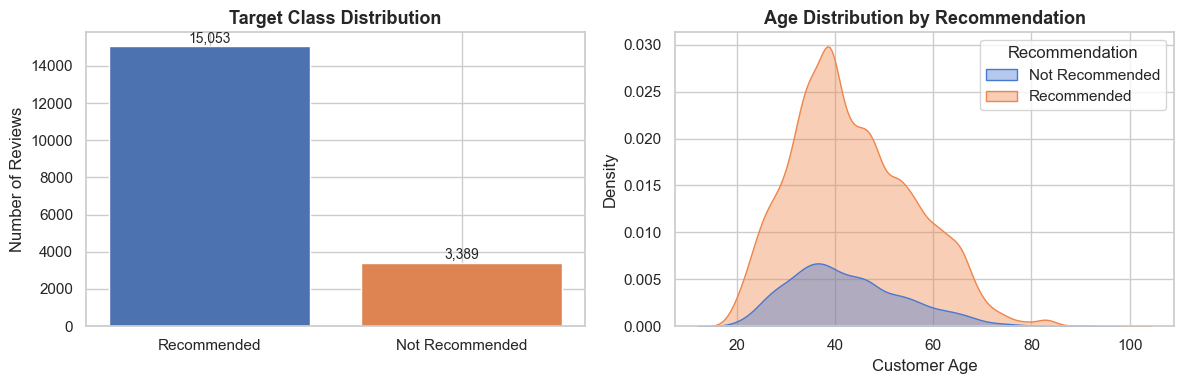

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Target balance ---
target_labels = target_counts.index.map(LABEL_MAP)
axes[0].bar(target_labels, target_counts.values, color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[0].set_title("Target Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Reviews")
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f"{val:,}", ha="center", va="bottom", fontsize=10)

# --- Age distribution by class ---
df_plot = df_raw.copy()
df_plot["Recommendation"] = df_plot["Recommended IND"].map(LABEL_MAP)
sns.kdeplot(data=df_plot, x="Age", hue="Recommendation", ax=axes[1], fill=True, alpha=0.4)
axes[1].set_title("Age Distribution by Recommendation", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Customer Age")

plt.tight_layout()
plt.show()


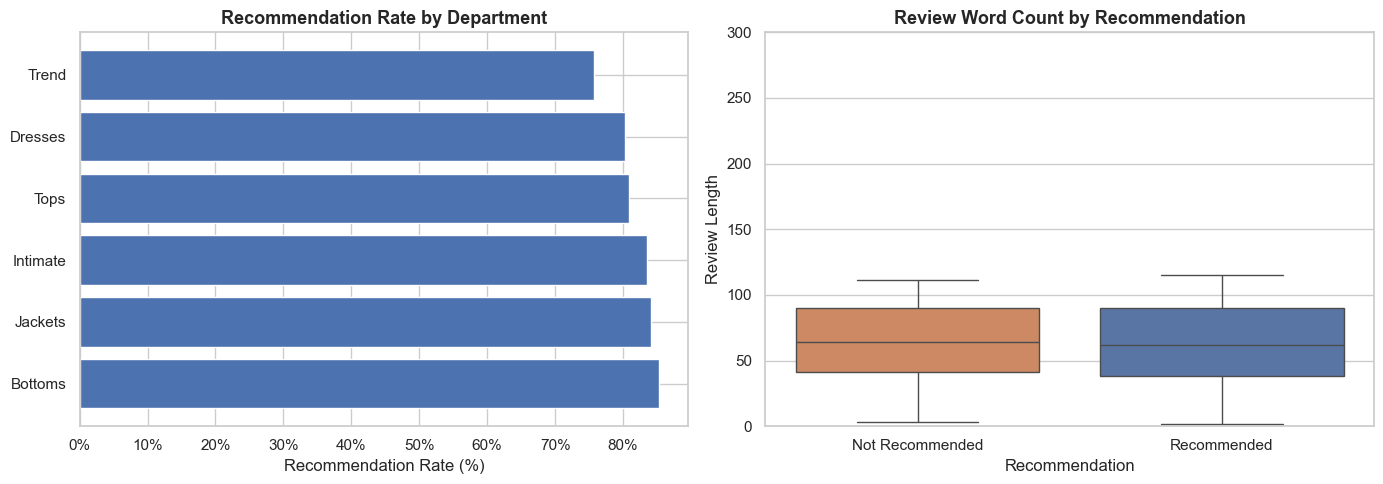

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Department name vs recommendation rate ---
dept_rec = (
    df_raw.groupby("Department Name")["Recommended IND"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(1)
)
axes[0].barh(dept_rec.index, dept_rec.values, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Recommendation Rate (%)")
axes[0].set_title("Recommendation Rate by Department", fontsize=13, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

# --- Review text length distribution ---
df_plot["Review Length"] = df_raw["Review Text"].str.split().str.len()
sns.boxplot(data=df_plot, x="Recommendation", y="Review Length", ax=axes[1],
            palette={"Recommended": "#4C72B0", "Not Recommended": "#DD8452"})
axes[1].set_title("Review Word Count by Recommendation", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()


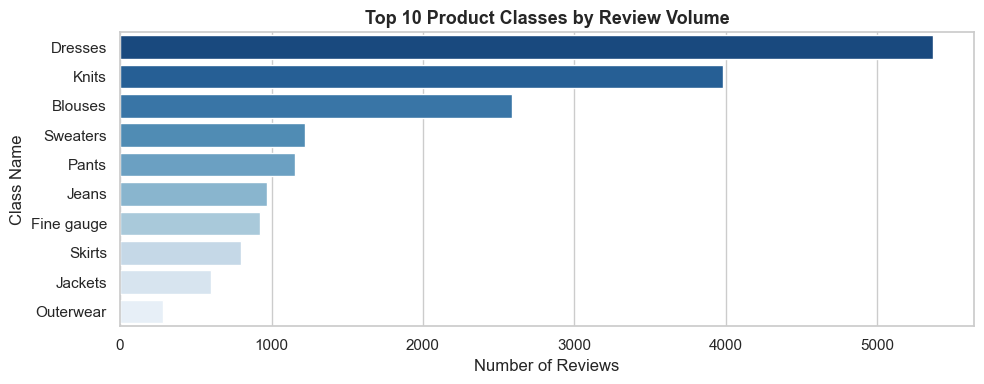

In [35]:
# Top 10 product classes by volume
class_counts = df_raw["Class Name"].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="Blues_r")
plt.title("Top 10 Product Classes by Review Volume", fontsize=13, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.tight_layout()
plt.show()


---
## 4. Feature Engineering


In [36]:
class RawTextCombiner(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        X["Full Review"] = (
            X["Title"].fillna("") + " " + X["Review Text"].fillna("")
        ).str.strip()
        # Drop columns consumed or not needed by any downstream step
        drop_cols = [c for c in ["Clothing ID", "Title", "Review Text"] if c in X.columns]
        return X.drop(columns=drop_cols)


In [37]:
class NLPFeatureAdder(BaseEstimator, TransformerMixin):

    @staticmethod
    def _sentiment(text: str) -> float:
        """TextBlob polarity in [-1, +1]."""
        if not isinstance(text, str) or not text.strip():
            return 0.0
        return TextBlob(text).sentiment.polarity

    @staticmethod
    def _adj_count(text: str) -> int:
        """Number of adjective tokens (JJ, JJR, JJS POS tags)."""
        if not isinstance(text, str) or not text.strip():
            return 0
        return sum(1 for _, tag in pos_tag(word_tokenize(text))
                   if tag.startswith("JJ"))

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        X["Sentiment Polarity"] = X["Full Review"].apply(self._sentiment)
        X["Adjective Count"]    = X["Full Review"].apply(self._adj_count)
        return X


In [38]:
class TextPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.stemmer_   = PorterStemmer()
        self.stopwords_ = set(stopwords.words("english"))

    def _clean(self, text: str) -> str:
        """Apply the full cleaning pipeline to a single string."""
        if not isinstance(text, str):
            return ""
        text  = text.lower()
        text  = re.sub(r"[^a-z\s]", " ", text)        # keep only letters + spaces
        tokens = text.split()
        tokens = [t for t in tokens if t not in self.stopwords_]
        tokens = [self.stemmer_.stem(t) for t in tokens]
        return " ".join(tokens)

    def fit(self, X, y=None):
        """No fitting required — returns self."""
        return self

    def transform(self, X):
        """Transform a Series or list of strings."""
        return pd.Series(X).fillna("").apply(self._clean)


# Quick sanity check
_demo = TextPreprocessor()
sample = "These beautiful dresses are absolutely stunning and I love them!"
print("Original :", sample)
print("Processed:", _demo._clean(sample))


Original : These beautiful dresses are absolutely stunning and I love them!
Processed: beauti dress absolut stun love


In [39]:
# ── Feature column names (post RawTextCombiner + NLPFeatureAdder) ──
TEXT_FEATURES        = "Full Review"
NUMERIC_FEATURES     = ["Age", "Positive Feedback Count", "Sentiment Polarity", "Adjective Count"]
CATEGORICAL_FEATURES = ["Division Name", "Department Name", "Class Name"]
TARGET               = "Recommended IND"


def build_pipeline() -> Pipeline:
    """
    Build the full end-to-end pipeline.

    Stages
    ------
    1. RawTextCombiner   — combine text columns, drop Clothing ID
    2. NLPFeatureAdder   — add Sentiment Polarity and Adjective Count
    3. ColumnTransformer — parallel preprocessing per feature type
       - text  : TextPreprocessor -> TfidfVectorizer
       - num   : SimpleImputer   -> StandardScaler
       - cat   : SimpleImputer   -> OneHotEncoder
    4. LogisticRegression

    Returns
    -------
    sklearn.pipeline.Pipeline (untrained)
    """

    # Text stream
    text_transformer = Pipeline([
        ("cleaner",    TextPreprocessor()),
        ("vectoriser", TfidfVectorizer(
            stop_words="english",
            max_features=8_000,
            ngram_range=(1, 2),
            sublinear_tf=True,
        )),
    ])

    # Numeric stream — imputer guards against missing values at inference
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    # Categorical stream — imputer guards against missing values at inference
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    # Fan-out by data type
    preprocessor = ColumnTransformer(
        transformers=[
            ("text", text_transformer,        TEXT_FEATURES),
            ("num",  numeric_transformer,     NUMERIC_FEATURES),
            ("cat",  categorical_transformer, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    pipeline = Pipeline([
        ("combiner",     RawTextCombiner()),
        ("nlp_features", NLPFeatureAdder()),
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1_000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])

    return pipeline


pipeline = build_pipeline()
print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  [{name}]  {type(step).__name__}")


Pipeline steps:
  [combiner]  RawTextCombiner
  [nlp_features]  NLPFeatureAdder
  [preprocessor]  ColumnTransformer
  [model]  LogisticRegression


---
## 5. Train / Test Split



In [40]:
X = df_raw.drop(columns=[TARGET])
y = df_raw[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).map(lambda x: f"{x:.1%}").rename(LABEL_MAP))


Training set : 14,753 samples
Test set     : 3,689 samples

Class balance in training set:
Recommended IND
Recommended        81.6%
Not Recommended    18.4%
Name: proportion, dtype: str


---
## 6. Training & Evaluation



In [41]:
# Fit only on training data — the test set is never seen by the pipeline here
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('combiner', ...), ('nlp_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

──────────────────────────────────────────────────
  Baseline Logistic Regression
──────────────────────────────────────────────────
  Accuracy : 0.8815
  ROC-AUC  : 0.9411

                 precision    recall  f1-score   support

Not Recommended       0.64      0.83      0.72       678
    Recommended       0.96      0.89      0.92      3011

       accuracy                           0.88      3689
      macro avg       0.80      0.86      0.82      3689
   weighted avg       0.90      0.88      0.89      3689



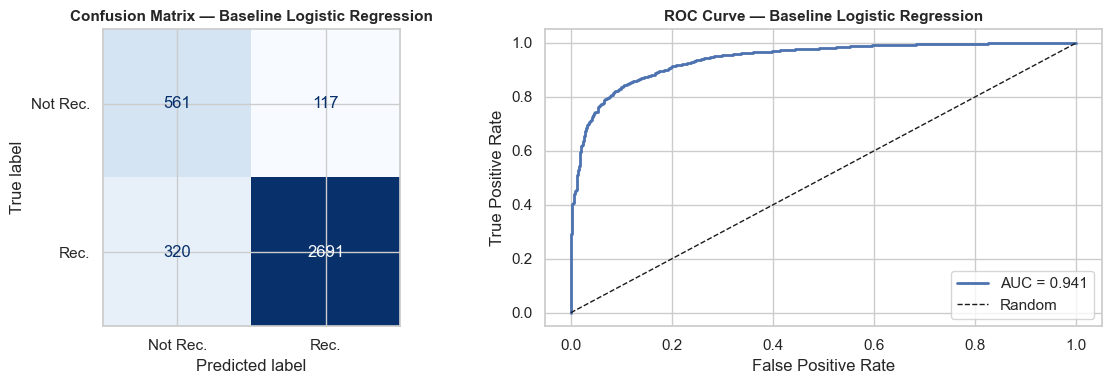

In [42]:
def evaluate_model(model, X_test, y_test, title="Model Evaluation"):
    
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    acc         = accuracy_score(y_test, y_pred)
    roc_auc     = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    print(f"{'─'*50}")
    print(f"  {title}")
    print(f"{'─'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Not Recommended", "Recommended"]))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Rec.", "Rec."])
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"Confusion Matrix — {title}", fontsize=11, fontweight="bold")

    # ROC curve
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}", color="#4C72B0")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve — {title}", fontsize=11, fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "roc_auc": roc_auc}


baseline_metrics = evaluate_model(pipeline, X_test, y_test, title="Baseline Logistic Regression")


---
## 7. Hyperparameter Tuning



In [43]:
param_grid = {
    "model__C":      [0.01, 0.1, 1, 10],   
    "model__solver": ["liblinear"],          
    "preprocessor__text__vectoriser__max_features": [8_000], 
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",    # optimise for AUC given class imbalance
    n_jobs=1,            # parallelise across all available CPU cores
    verbose=1,
    refit=True,           # refit best estimator on full training data
)

grid_search.fit(X_train, y_train)
print(f"\nGrid search complete — {len(grid_search.cv_results_['params'])} parameter combinations evaluated.")


Fitting 3 folds for each of 4 candidates, totalling 12 fits

Grid search complete — 4 parameter combinations evaluated.


In [44]:
print("Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validated ROC-AUC: {grid_search.best_score_:.4f}")


Best hyperparameters found:
  model__C: 1
  model__solver: liblinear
  preprocessor__text__vectoriser__max_features: 8000

Best cross-validated ROC-AUC: 0.9390


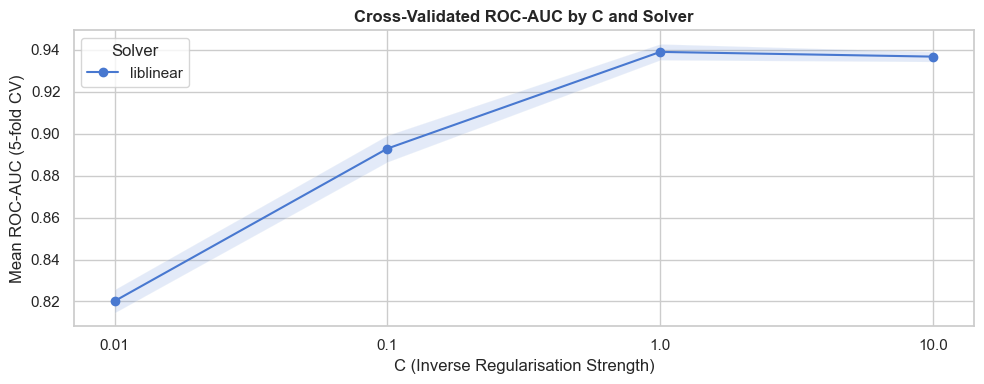

In [45]:
# Cross-validation results — version-stable bar chart
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["C"]      = cv_results["param_model__C"].astype(str)
cv_results["solver"] = cv_results["param_model__solver"].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
for solver, grp in cv_results.groupby("solver"):
    ax.plot(grp["C"], grp["mean_test_score"], marker="o", label=solver)
    ax.fill_between(
        grp["C"],
        grp["mean_test_score"] - grp["std_test_score"],
        grp["mean_test_score"] + grp["std_test_score"],
        alpha=0.15,
    )
ax.set_title("Cross-Validated ROC-AUC by C and Solver", fontsize=12, fontweight="bold")
ax.set_xlabel("C (Inverse Regularisation Strength)")
ax.set_ylabel("Mean ROC-AUC (5-fold CV)")
ax.legend(title="Solver")
plt.tight_layout()
plt.show()


---
## 8. Final Evaluation


──────────────────────────────────────────────────
  Tuned Logistic Regression
──────────────────────────────────────────────────
  Accuracy : 0.8821
  ROC-AUC  : 0.9411

                 precision    recall  f1-score   support

Not Recommended       0.64      0.83      0.72       678
    Recommended       0.96      0.89      0.93      3011

       accuracy                           0.88      3689
      macro avg       0.80      0.86      0.82      3689
   weighted avg       0.90      0.88      0.89      3689



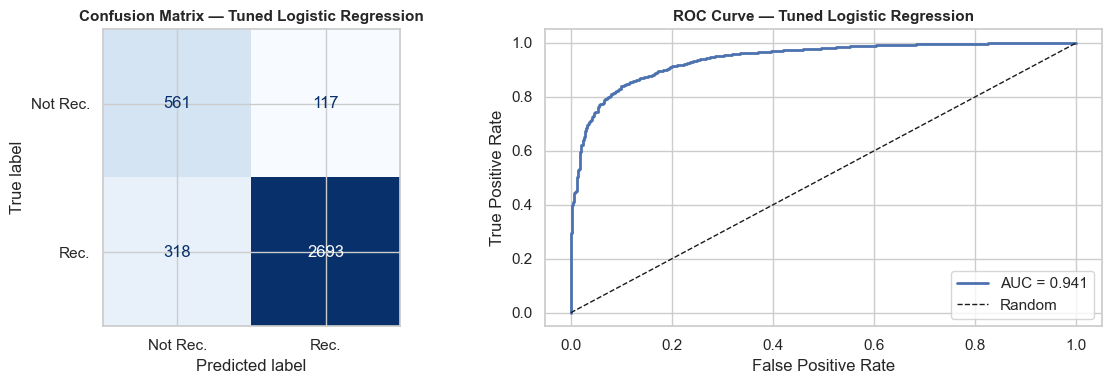

In [46]:
best_pipeline = grid_search.best_estimator_

tuned_metrics = evaluate_model(best_pipeline, X_test, y_test, title="Tuned Logistic Regression")


In [48]:
# Baseline vs tuned comparison
comparison = pd.DataFrame({
    "Metric":   ["Accuracy", "ROC-AUC"],
    "Baseline": [baseline_metrics["accuracy"], baseline_metrics["roc_auc"]],
    "Tuned":    [tuned_metrics["accuracy"],    tuned_metrics["roc_auc"]],
}).set_index("Metric")

comparison["Improvement"] = comparison["Tuned"] - comparison["Baseline"]
print("Performance comparison (test set):")
display(comparison.style.format("{:.4f}"))


Performance comparison (test set):


,Baseline,Tuned,Improvement
Metric,,,
Accuracy,0.8815,0.8821,0.0005
ROC-AUC,0.9411,0.9411,0.0000


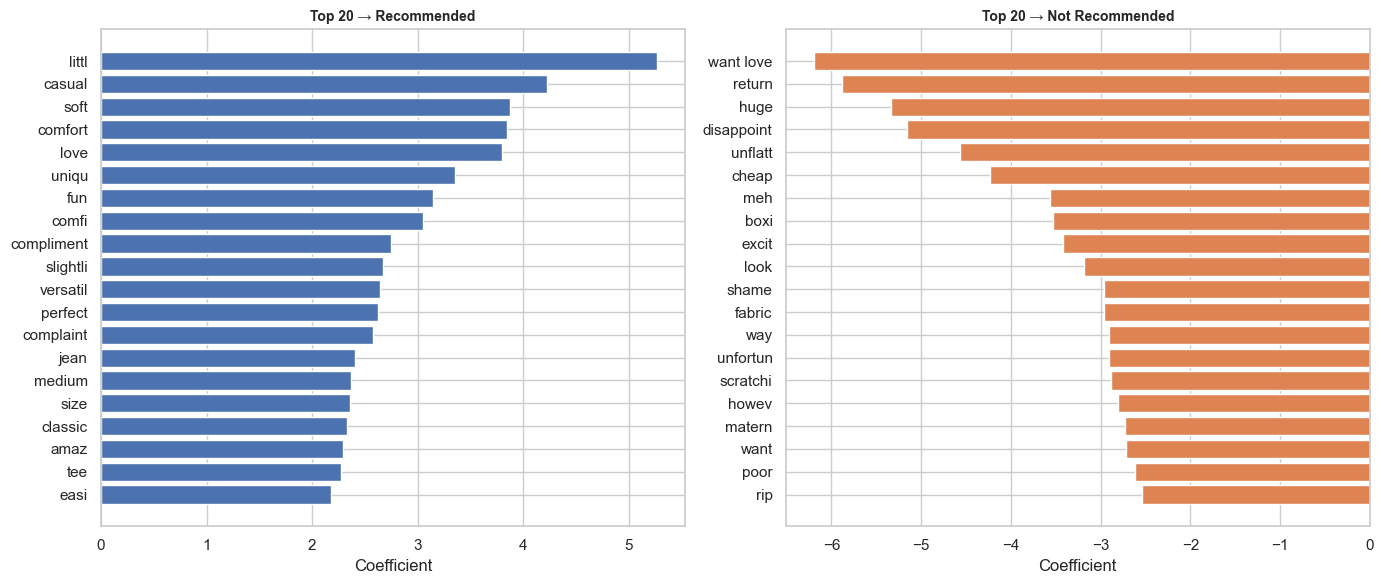

In [49]:
def plot_top_tfidf_features(pipeline, n: int = 20):
    """Plot the top positive and negative logistic regression coefficients."""
    col_transformer = pipeline.named_steps["preprocessor"]
    clf             = pipeline.named_steps["model"]

    text_pipe     = col_transformer.named_transformers_["text"]
    tfidf         = text_pipe.named_steps["vectoriser"]
    text_features = tfidf.get_feature_names_out()

    ohe           = col_transformer.named_transformers_["cat"].named_steps["encoder"]
    cat_features  = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
    all_features  = np.concatenate(
        [text_features, np.array(NUMERIC_FEATURES), cat_features]
    )

    coefs        = clf.coef_[0]
    top_pos_idx  = np.argsort(coefs)[-n:][::-1]
    top_neg_idx  = np.argsort(coefs)[:n]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, idx, title, color in [
        (axes[0], top_pos_idx, f"Top {n} → Recommended",     "#4C72B0"),
        (axes[1], top_neg_idx, f"Top {n} → Not Recommended", "#DD8452"),
    ]:
        ax.barh(all_features[idx][::-1], coefs[idx][::-1], color=color)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Coefficient")
    plt.tight_layout()
    plt.show()


plot_top_tfidf_features(best_pipeline, n=20)


---
## 9. Save Pipeline

In [51]:
import os
import shutil

MODEL_PATH = "pipeline.pkl"

# Remove stale directory if present (can occur on repeated runs)
if os.path.isdir(MODEL_PATH):
    shutil.rmtree(MODEL_PATH)

joblib.dump(best_pipeline, MODEL_PATH)
print(f"Pipeline saved to: {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")


Pipeline saved to: pipeline.pkl
File size: 426.2 KB


In [52]:
# ── Verify the saved pipeline loads and predicts on a raw input ─────────────
loaded = joblib.load(MODEL_PATH)

test_raw = pd.DataFrame([{
    "Clothing ID": 0,
    "Age": 28,
    "Title": "Great quality",
    "Review Text": "Fantastic dress, beautiful material and perfect sizing.",
    "Positive Feedback Count": 5,
    "Division Name": "General",
    "Department Name": "Dresses",
    "Class Name": "Dresses",
}])

pred  = loaded.predict(test_raw)[0]
proba = loaded.predict_proba(test_raw)[0][1]
print(f"Prediction : {LABEL_MAP[pred]}")
print(f"Confidence : {proba:.1%}")
print("\nSaved pipeline loads and predicts correctly on raw input.")


Prediction : Recommended
Confidence : 96.0%

Saved pipeline loads and predicts correctly on raw input.
